# UK Retail Sales — Customer Segmentation (RFM Analysis)

**Project:** UK Retail Sales Analytics  
**Notebook:** 03 — Customer Segmentation  
**Dataset:** 60,000 transactions | 8,000 customers  
**Period:** January 2022 – December 2024  
**Author:** Manvendra Singh

---

## Purpose

Not all customers are equal. This notebook segments the customer base using RFM Analysis — a framework used across retail, banking, and e-commerce to understand customer value and behaviour.

**RFM stands for:**
- **Recency** — how recently did the customer last purchase?
- **Frequency** — how often do they buy?
- **Monetary** — how much have they spent in total?

Each customer gets a score on all three dimensions. Combining those scores places every customer into a meaningful business segment — Champions, Loyal, At-Risk, or Lost — so the business knows exactly who to reward, who to re-engage, and who has already gone.

## Business Questions

1. Who are the Champions — the customers buying frequently, recently, and spending the most?
2. How many customers are At-Risk or Lost — and what is the revenue at stake?
3. Does the RFM segmentation align with the loyalty tier system, or contradict it?
4. Where should the business focus its retention and re-engagement effort?

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Load cleaned datasets
customers_df = pd.read_csv('cleaned_customers.csv', parse_dates=['registration_date'])
trans_df     = pd.read_csv('cleaned_transactions.csv', parse_dates=['transaction_date'])

# Work with completed orders only
completed = trans_df[trans_df['order_status'] == 'Completed'].copy()

print('Datasets loaded')
print(f'  Completed transactions: {len(completed):,}')
print(f'  Unique customers in transactions: {completed["customer_id"].nunique():,}')

Datasets loaded
  Completed transactions: 46,613
  Unique customers in transactions: 7,980


---
## 1. Building the RFM Table

Calculating the three RFM values for every customer from the transaction history.

Using **1 January 2025** as the snapshot date — treating it as "today" so recency is calculated relative to the end of the data period.

In [2]:
snapshot_date = pd.Timestamp('2025-01-01')

rfm = completed.groupby('customer_id').agg(
    recency   = ('transaction_date', lambda x: (snapshot_date - x.max()).days),
    frequency = ('transaction_id', 'count'),
    monetary  = ('total_revenue', 'sum')
).reset_index()

print('RFM table built')
print(f'  Customers with purchase history: {len(rfm):,}')
print()
print(rfm.describe().round(2))

RFM table built
  Customers with purchase history: 7,980

       recency  frequency  monetary
count  7980.00    7980.00   7980.00
mean    184.59       5.84    640.03
std     179.43       2.39    506.59
min       1.00       1.00      1.79
25%      53.00       4.00    272.19
50%     130.00       6.00    508.80
75%     258.00       7.00    871.08
max    1095.00      16.00   4826.31


> **Finding:** The average customer last bought 185 days ago — six months of silence from a typical buyer. Purchase frequency ranges from 1 to 16 orders but the median is 6, so most customers are occasional rather than habitual. The spend distribution is wide: median spend is £509 but the mean is £640, pulled up by high-value outliers. Some customers have spent less than £2 total; the top end hits £4,826. Averages hide that gap — which is exactly what RFM is built to surface.

---
## 2. Scoring Each Customer (1–4)

Each customer is scored 1 to 4 on each RFM dimension using quartiles — dividing the customer base into four equal groups.

**Scoring direction:**
- Recency: lower days = more recent = better → reverse scoring (4 = most recent)
- Frequency and Monetary: higher = better → higher values get higher scores

In [3]:
# Recency: lower days = more recent = better → reverse scoring (4 = most recent)
rfm['r_score'] = pd.qcut(rfm['recency'], q=4, labels=[4, 3, 2, 1]).astype(int)

# Frequency: higher = better
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)

# Monetary: higher = better
rfm['m_score'] = pd.qcut(rfm['monetary'], q=4, labels=[1, 2, 3, 4]).astype(int)

# Combined RFM score string (e.g. '444' = Champion)
rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

# Average RFM score (single number summary)
rfm['rfm_avg'] = ((rfm['r_score'] + rfm['f_score'] + rfm['m_score']) / 3).round(2)

print('RFM scores assigned')
print(rfm[['customer_id', 'recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score']].head(10))

RFM scores assigned
  customer_id  recency  frequency  monetary  r_score  f_score  m_score  \
0   CUST00001       13          7    380.45        4        3        2   
1   CUST00002      384          7    402.58        1        3        2   
2   CUST00003      193          4    392.61        2        1        2   
3   CUST00004       22          6   1156.92        4        2        4   
4   CUST00005       97          6    513.59        3        2        3   
5   CUST00006      190          7   1902.90        2        3        4   
6   CUST00007      369          4    187.57        1        1        1   
7   CUST00008      192          6    251.98        2        2        1   
8   CUST00009      156          3    115.78        2        1        1   
9   CUST00010      143          4    570.48        2        1        3   

  rfm_score  
0       432  
1       132  
2       212  
3       424  
4       323  
5       234  
6       111  
7       221  
8       211  
9       213  


---
## 3. Assigning Customer Segments

RFM scores are mapped to business-meaningful segments. These labels are what marketing and retention teams actually use — more actionable than a number.

In [4]:
def assign_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champion'
    elif r >= 3 and f >= 2:
        return 'Loyal'
    elif r >= 3 and f == 1:
        return 'New Customer'
    elif r == 2 and f >= 2:
        return 'At Risk'
    elif r == 2 and f == 1:
        return 'Needs Attention'
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

print('Segment distribution:')
print(rfm['segment'].value_counts())
print()
print('As percentage:')
print((rfm['segment'].value_counts(normalize=True) * 100).round(1))

Segment distribution:
segment
Lost               1986
Champion           1783
Loyal              1561
At Risk            1537
New Customer        652
Needs Attention     461
Name: count, dtype: int64

As percentage:
segment
Lost               24.9
Champion           22.3
Loyal              19.6
At Risk            19.3
New Customer        8.2
Needs Attention     5.8
Name: proportion, dtype: float64


> **Finding:** 1,783 Champions — 22.3% of the customer base. That's a solid core. The concern is at the other end: Lost is the single largest segment at 24.9% (1,986 customers), and At-Risk adds another 19.3% (1,537). Nearly 45% of the base has either gone quiet or already left. For a business running a loyalty programme, that's a problem. A well-functioning programme should be catching At-Risk customers before they become Lost — and the data suggests it isn't.

---
## 4. Segment Revenue Analysis

How much revenue each segment contributes — this tells the business where its money actually comes from and what it stands to lose if certain segments churn.

In [5]:
segment_summary = rfm.groupby('segment').agg(
    customers       = ('customer_id', 'count'),
    total_revenue   = ('monetary', 'sum'),
    avg_spend       = ('monetary', 'mean'),
    avg_recency     = ('recency', 'mean'),
    avg_frequency   = ('frequency', 'mean')
).reset_index()

segment_summary['revenue_share'] = (segment_summary['total_revenue'] / segment_summary['total_revenue'].sum() * 100).round(1)
segment_summary['avg_spend']     = segment_summary['avg_spend'].round(2)
segment_summary['avg_recency']   = segment_summary['avg_recency'].round(0).astype(int)
segment_summary['avg_frequency'] = segment_summary['avg_frequency'].round(1)
segment_summary = segment_summary.sort_values('total_revenue', ascending=False)

print(segment_summary.to_string(index=False))

        segment  customers  total_revenue  avg_spend  avg_recency  avg_frequency  revenue_share
       Champion       1783     1906023.22    1069.00           55            8.3           37.3
        At Risk       1537     1116280.32     726.27          185            6.7           21.9
           Lost       1986      957535.57     482.14          439            4.5           18.7
          Loyal       1561      739736.09     473.89           59            5.8           14.5
   New Customer        652      233852.35     358.67           61            3.2            4.6
Needs Attention        461      153980.17     334.01          189            3.2            3.0


> **Finding:** Champions are 22% of customers but drive 37.3% of revenue — £1.9M out of £5.1M total. That concentration is the most important number in this notebook. At the other end, Lost customers (24.9% of the base) contribute 18.7% of revenue, with an average spend of £482 versus Champions at £1,069 — less than half. The At-Risk segment is the most urgent: 1,537 customers who used to spend £726 on average and haven't bought in 185 days. That's £1.1M in revenue actively disengaging.

C:\Users\MANVE\AppData\Local\Temp\ipykernel_8\3349246763.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(segment_summary['segment'], rotation=30, ha='right')
C:\Users\MANVE\AppData\Local\Temp\ipykernel_8\3349246763.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(segment_summary['segment'], rotation=30, ha='right')


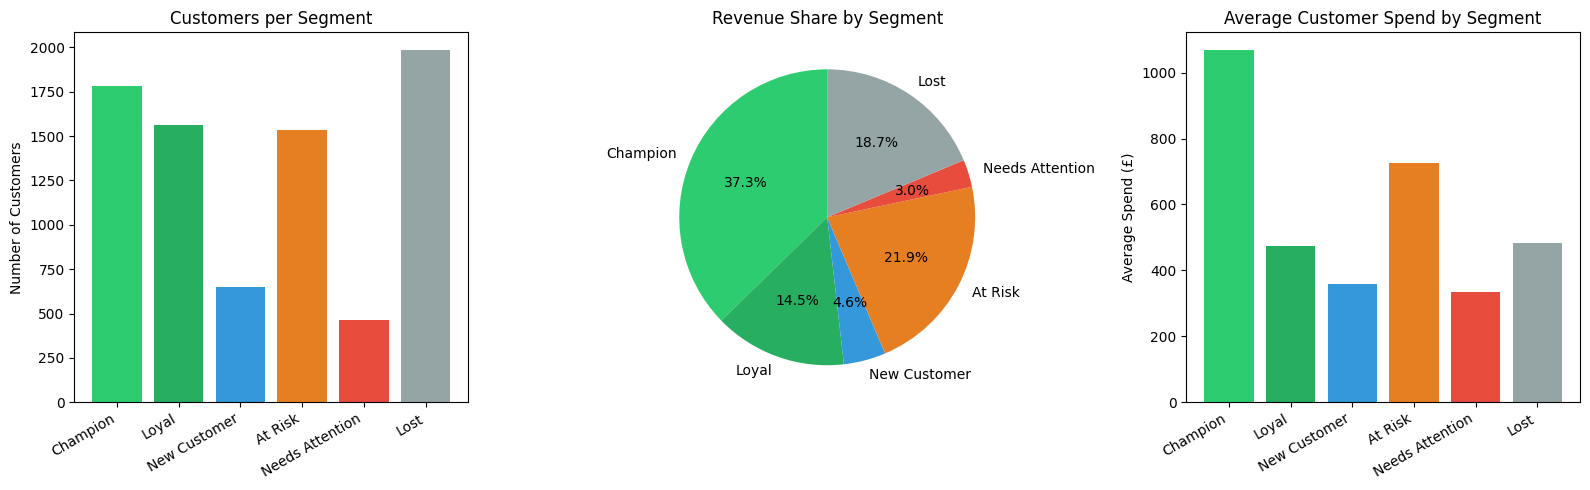

In [6]:
seg_order   = ['Champion', 'Loyal', 'New Customer', 'At Risk', 'Needs Attention', 'Lost']
seg_colours = ['#2ecc71', '#27ae60', '#3498db', '#e67e22', '#e74c3c', '#95a5a6']
colour_map  = dict(zip(seg_order, seg_colours))

segment_summary['segment'] = pd.Categorical(segment_summary['segment'], categories=seg_order, ordered=True)
segment_summary = segment_summary.sort_values('segment')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Customer count by segment
colours = [colour_map[s] for s in segment_summary['segment']]
axes[0].bar(segment_summary['segment'], segment_summary['customers'], color=colours)
axes[0].set_title('Customers per Segment', fontsize=12)
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(segment_summary['segment'], rotation=30, ha='right')

# Revenue share by segment
axes[1].pie(segment_summary['revenue_share'],
            labels=segment_summary['segment'],
            colors=colours,
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Revenue Share by Segment', fontsize=12)

# Average spend by segment
axes[2].bar(segment_summary['segment'], segment_summary['avg_spend'], color=colours)
axes[2].set_title('Average Customer Spend by Segment', fontsize=12)
axes[2].set_ylabel('Average Spend (£)')
axes[2].set_xticklabels(segment_summary['segment'], rotation=30, ha='right')

plt.tight_layout()
plt.show()

---
## 5. RFM vs Loyalty Tier — Does the Programme Work?

The EDA found that Bronze customers outspend Platinum — which contradicts what a loyalty programme should achieve. Crossing RFM segments with loyalty tiers here to see whether the two systems align.

In [7]:
# Merge RFM results with customer loyalty tier
rfm_loyalty = rfm.merge(customers_df[['customer_id', 'loyalty_tier']], on='customer_id', how='left')

# Cross-tabulation: what RFM segment are customers in each loyalty tier?
cross_tab = pd.crosstab(
    rfm_loyalty['loyalty_tier'],
    rfm_loyalty['segment'],
    normalize='index'
).round(3) * 100

# Order tiers and segments logically
tier_order = ['Bronze', 'Silver', 'Gold', 'Platinum']
cross_tab  = cross_tab.reindex(tier_order)

print('% of customers in each RFM segment by Loyalty Tier:')
print(cross_tab.to_string())
print()

# Average RFM score by loyalty tier
print('Average RFM score by Loyalty Tier:')
print(rfm_loyalty.groupby('loyalty_tier')['rfm_avg'].mean().reindex(tier_order).round(2))

% of customers in each RFM segment by Loyalty Tier:
segment       At Risk  Champion  Lost  Loyal  Needs Attention  New Customer
loyalty_tier                                                               
Bronze           18.2      23.4  25.1   19.2              5.8           8.3
Silver           20.5      23.0  24.1   18.9              5.5           8.0
Gold             18.9      19.5  26.0   21.5              6.4           7.7
Platinum         21.5      19.9  24.3   19.9              5.1           9.3

Average RFM score by Loyalty Tier:
loyalty_tier
Bronze      2.52
Silver      2.51
Gold        2.46
Platinum    2.43
Name: rfm_avg, dtype: float64


> **Finding:** The loyalty programme doesn't work — the numbers are clear. Platinum customers have the lowest average RFM score (2.43) of any tier. Bronze scores highest at 2.52. The Champion concentration across tiers is almost flat: Bronze produces 23.4% Champions, Platinum just 19.9%. Platinum has more Lost customers (24.3%) than Champions (19.9%). The tier system is assigning status based on something other than actual purchase behaviour, and it's doing it in reverse order of value.

---
## 6. At-Risk & Lost Customer Analysis

Quantifying the revenue at stake from customers who have disengaged — the business case for a re-engagement campaign.

In [8]:
at_risk = rfm[rfm['segment'] == 'At Risk']
lost    = rfm[rfm['segment'] == 'Lost']

print('=== AT-RISK CUSTOMERS ===')
print(f'  Count:              {len(at_risk):,}')
print(f'  Total past revenue: £{at_risk["monetary"].sum():,.0f}')
print(f'  Avg spend:          £{at_risk["monetary"].mean():,.2f}')
print(f'  Avg days since last purchase: {at_risk["recency"].mean():.0f} days')
print()
print('=== LOST CUSTOMERS ===')
print(f'  Count:              {len(lost):,}')
print(f'  Total past revenue: £{lost["monetary"].sum():,.0f}')
print(f'  Avg spend:          £{lost["monetary"].mean():,.2f}')
print(f'  Avg days since last purchase: {lost["recency"].mean():.0f} days')
print()

# Revenue recovery scenario
combined_revenue = at_risk['monetary'].sum() + lost['monetary'].sum()
print(f'Total revenue from At-Risk + Lost customers: £{combined_revenue:,.0f}')
print(f'If 20% reactivated at avg historical spend:')
print(f'  Potential recovered revenue: £{combined_revenue * 0.20:,.0f}')

=== AT-RISK CUSTOMERS ===
  Count:              1,537
  Total past revenue: £1,116,280
  Avg spend:          £726.27
  Avg days since last purchase: 185 days

=== LOST CUSTOMERS ===
  Count:              1,986
  Total past revenue: £957,536
  Avg spend:          £482.14
  Avg days since last purchase: 439 days

Total revenue from At-Risk + Lost customers: £2,073,816
If 20% reactivated at avg historical spend:
  Potential recovered revenue: £414,763


> **Finding:** At-Risk and Lost combined: 3,523 customers representing £2,073,816 in historical revenue — 40% of the customer base, roughly 40% of total revenue. Money the business has already earned from customers it is in the process of losing. A 20% reactivation rate at historical spend levels recovers £414,763. A targeted campaign doesn't need to be expensive to pay for itself.

---
## 7. Champion Profile

Understanding who Champions are is as important as knowing who is at risk. These are the customers worth protecting and learning from.

In [9]:
champions = rfm[rfm['segment'] == 'Champion'].merge(
    customers_df[['customer_id', 'age_group', 'region', 'loyalty_tier', 'gender']],
    on='customer_id', how='left'
)

print('=== CHAMPION CUSTOMER PROFILE ===')
print(f'  Total Champions:        {len(champions):,}')
print(f'  Avg days since purchase: {champions["recency"].mean():.0f} days')
print(f'  Avg purchase frequency:  {champions["frequency"].mean():.1f} orders')
print(f'  Avg total spend:         £{champions["monetary"].mean():,.2f}')
print()
print('Champions by Age Group:')
print(champions['age_group'].value_counts())
print()
print('Champions by Region:')
print(champions['region'].value_counts().head(5))
print()
print('Champions by Loyalty Tier:')
print(champions['loyalty_tier'].value_counts())

=== CHAMPION CUSTOMER PROFILE ===
  Total Champions:        1,783
  Avg days since purchase: 55 days
  Avg purchase frequency:  8.3 orders
  Avg total spend:         £1,069.00

Champions by Age Group:
age_group
55-64    319
45-54    308
35-44    298
18-24    295
65+      284
25-34    279
Name: count, dtype: int64

Champions by Region:
region
London           377
South East       243
North West       193
Yorkshire        174
West Midlands    157
Name: count, dtype: int64

Champions by Loyalty Tier:
loyalty_tier
Bronze      840
Silver      547
Gold        274
Platinum    122
Name: count, dtype: int64


> **Finding:** Champions are spread almost evenly across age groups — 55–64 leads narrowly with 319, followed by 45–54 (308) and 35–44 (298). No single dominant demographic. Regionally, London leads with 377 Champions, then South East (243) and North West (193). The loyalty tier breakdown is the most telling: 840 of the 1,783 Champions — nearly half — are Bronze tier. Another 547 are Silver. Only 122 hold Platinum. The business's most valuable customers are, in the main, its least recognised.

---
## 8. RFM Distribution Visualisation

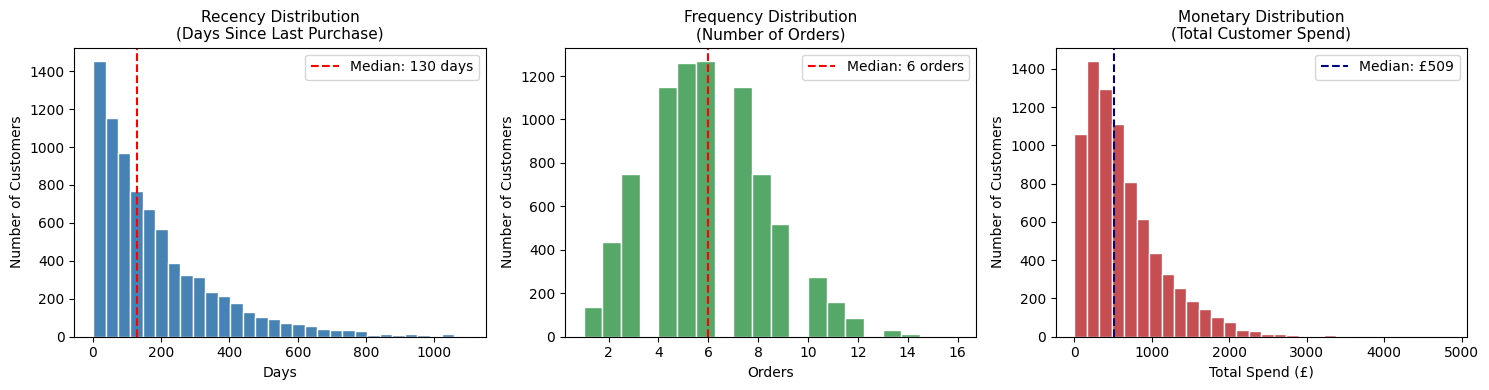

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Recency distribution
axes[0].hist(rfm['recency'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Recency Distribution\n(Days Since Last Purchase)', fontsize=11)
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of Customers')
axes[0].axvline(rfm['recency'].median(), color='red', linestyle='--', label=f'Median: {rfm["recency"].median():.0f} days')
axes[0].legend()

# Frequency distribution
axes[1].hist(rfm['frequency'], bins=20, color='#55A868', edgecolor='white')
axes[1].set_title('Frequency Distribution\n(Number of Orders)', fontsize=11)
axes[1].set_xlabel('Orders')
axes[1].set_ylabel('Number of Customers')
axes[1].axvline(rfm['frequency'].median(), color='red', linestyle='--', label=f'Median: {rfm["frequency"].median():.0f} orders')
axes[1].legend()

# Monetary distribution
axes[2].hist(rfm['monetary'], bins=30, color='#C44E52', edgecolor='white')
axes[2].set_title('Monetary Distribution\n(Total Customer Spend)', fontsize=11)
axes[2].set_xlabel('Total Spend (£)')
axes[2].set_ylabel('Number of Customers')
axes[2].axvline(rfm['monetary'].median(), color='navy', linestyle='--', label=f'Median: £{rfm["monetary"].median():.0f}')
axes[2].legend()

plt.tight_layout()
plt.show()

> **Finding:** All three distributions are right-skewed — normal for retail but worth being explicit about. The recency tail stretches to 1,095 days, confirming there's a genuine Lost segment, not just lapsed buyers. Frequency clusters tightly between 4 and 7 orders for most customers — even engaged buyers aren't frequent. Monetary is the most skewed: most customers sit below £500 total spend, but a tail of high spenders runs past £2,000. Those outliers are disproportionately important to protect.

---
## 9. Saving RFM Results

Saving the full RFM table with segment labels for use in the recommendations notebook and Power BI dashboard.

In [11]:
# Merge with customer details for the full enriched table
rfm_full = rfm.merge(
    customers_df[['customer_id', 'age_group', 'gender', 'region', 'loyalty_tier', 'is_active']],
    on='customer_id', how='left'
)

rfm_full.to_csv('rfm_segments.csv', index=False)

print(f'RFM segments saved: {len(rfm_full):,} customers')
print()
print('Columns saved:')
print(list(rfm_full.columns))

RFM segments saved: 7,980 customers

Columns saved:
['customer_id', 'recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score', 'rfm_avg', 'segment', 'age_group', 'gender', 'region', 'loyalty_tier', 'is_active']


---
## 10. Segmentation Summary & Business Recommendations

Translating the RFM findings into specific actions per segment.

In [12]:
print('=== FINAL SEGMENT SUMMARY ===')
for _, row in segment_summary.iterrows():
    print(f"\n{row['segment'].upper()}")
    print(f"  Customers:     {row['customers']:,}")
    print(f"  Revenue share: {row['revenue_share']}%")
    print(f"  Avg spend:     £{row['avg_spend']:,.2f}")
    print(f"  Avg recency:   {row['avg_recency']} days")
    print(f"  Avg frequency: {row['avg_frequency']} orders")

=== FINAL SEGMENT SUMMARY ===

CHAMPION
  Customers:     1,783
  Revenue share: 37.3%
  Avg spend:     £1,069.00
  Avg recency:   55 days
  Avg frequency: 8.3 orders

LOYAL
  Customers:     1,561
  Revenue share: 14.5%
  Avg spend:     £473.89
  Avg recency:   59 days
  Avg frequency: 5.8 orders

NEW CUSTOMER
  Customers:     652
  Revenue share: 4.6%
  Avg spend:     £358.67
  Avg recency:   61 days
  Avg frequency: 3.2 orders

AT RISK
  Customers:     1,537
  Revenue share: 21.9%
  Avg spend:     £726.27
  Avg recency:   185 days
  Avg frequency: 6.7 orders

NEEDS ATTENTION
  Customers:     461
  Revenue share: 3.0%
  Avg spend:     £334.01
  Avg recency:   189 days
  Avg frequency: 3.2 orders

LOST
  Customers:     1,986
  Revenue share: 18.7%
  Avg spend:     £482.14
  Avg recency:   439 days
  Avg frequency: 4.5 orders


---
## Recommendations by Segment

| Segment | Strategy | Specific Action |
|---|---|---|
| **Champion** | Protect and reward | Exclusive early access, VIP events, personalised acknowledgement. These customers must not feel taken for granted |
| **Loyal** | Upsell and deepen | Cross-category promotions — Loyal customers buy regularly but may be limited to one category |
| **New Customer** | Convert to Loyal | Welcome sequence, second purchase incentive within 30 days. The first repeat purchase is the critical moment |
| **At Risk** | Re-engage urgently | Personalised win-back offer within 30 days. Time-sensitive — these customers are disengaging but not gone |
| **Needs Attention** | Low-cost nudge | Email re-engagement with product recommendations based on past purchases |
| **Lost** | Assess ROI carefully | Win-back campaign only for high-spend Lost customers — not all are worth the cost of reacquisition |

---

## Segmentation Summary — Key Findings

| Area | Finding |
|---|---|
| Total customers segmented | 7,980 customers with completed transaction history |
| Champion count & revenue share | 1,783 Champions — 22.3% of customers, 37.3% of revenue (£1.9M) |
| At-Risk + Lost revenue at stake | 3,523 customers, £2,073,816 in historical revenue — 20% reactivation = £414,763 recovered |
| Loyalty vs RFM alignment | No alignment — Platinum has the lowest avg RFM score (2.43); Bronze scores highest (2.52) |
| Top Champion age group | 55–64 (319 Champions), spread near-even across all age groups |
| Top Champion region | London (377 Champions), South East (243), North West (193) |

---